# Bond Pricing Tutorial

This tutorial demonstrates how to price bonds and bond options in QuantStrata, covering:

1. **Zero Coupon Bonds**: Single cash flow pricing and duration
2. **Fixed Rate Bonds**: Coupon bond pricing, clean/dirty prices, YTM
3. **Bond Risk Measures**: DV01, duration, convexity
4. **Bond Options**: Black76 pricing for call/put options on bonds

## Setup

In [1]:
# Standard imports
import sys
sys.path.insert(0, '../../..')

import numpy as np
import matplotlib.pyplot as plt

# QuantStrata imports - Bond Instruments
from src.instruments.ir.linear.bond import (
    IrBondZeroCouponSimple,
    IrBondFixedRateSimple,
)
from src.instruments.ir.options.bond import (
    IrBondEuropeanOptionSimple,
)

# QuantStrata imports - Bond Pricers
from src.pricers.ir.bond import (
    IrBondZeroCouponPricerSimple,
    IrBondFixedRatePricerSimple,
)
from src.pricers.ir.european_b76 import (
    IrBondEuropeanOptionB76PricerSimple,
)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("QuantStrata Bond Pricing loaded successfully!")

QuantStrata Bond Pricing loaded successfully!


---

## Part 1: Zero Coupon Bonds

A zero coupon bond pays a single cash flow (face value) at maturity. It's the simplest bond and the building block for yield curves.

### 1.1 Zero Coupon Bond Pricing

$$PV = Face \times DF(T)$$

Where $DF(T) = e^{-rT}$ for continuously compounded rates.

In [2]:
# Create a 5-year zero coupon bond
zc_bond = IrBondZeroCouponSimple(
    face_value=100.0,
    maturity=5.0,
    discount_factor=0.85,  # ~3.25% zero rate
)

pricer = IrBondZeroCouponPricerSimple()

# Price and risk measures
pv = pricer.price(zc_bond)
greeks = pricer.greeks(zc_bond)

print("=== Zero Coupon Bond ===")
print(f"Face Value:    ${zc_bond.face_value:.2f}")
print(f"Maturity:      {zc_bond.maturity:.1f} years")
print(f"Present Value: ${pv:.4f}")
print(f"Implied Rate:  {zc_bond.implied_zero_rate:.4%}")
print()
print("=== Risk Measures ===")
print(f"DV01:             ${greeks['dv01']:.4f}")
print(f"Macaulay Duration: {greeks['macaulay_duration']:.4f} years")
print(f"Modified Duration: {greeks['modified_duration']:.4f}")
print(f"Convexity:        {greeks['convexity']:.4f}")

=== Zero Coupon Bond ===
Face Value:    $100.00
Maturity:      5.0 years
Present Value: $85.0000
Implied Rate:  3.2504%

=== Risk Measures ===
DV01:             $0.0425
Macaulay Duration: 5.0000 years
Modified Duration: 5.0000
Convexity:        25.0000


### 1.2 Zero Coupon Bond Price vs Yield

Bond prices move inversely to yields. The relationship is convex (not linear).

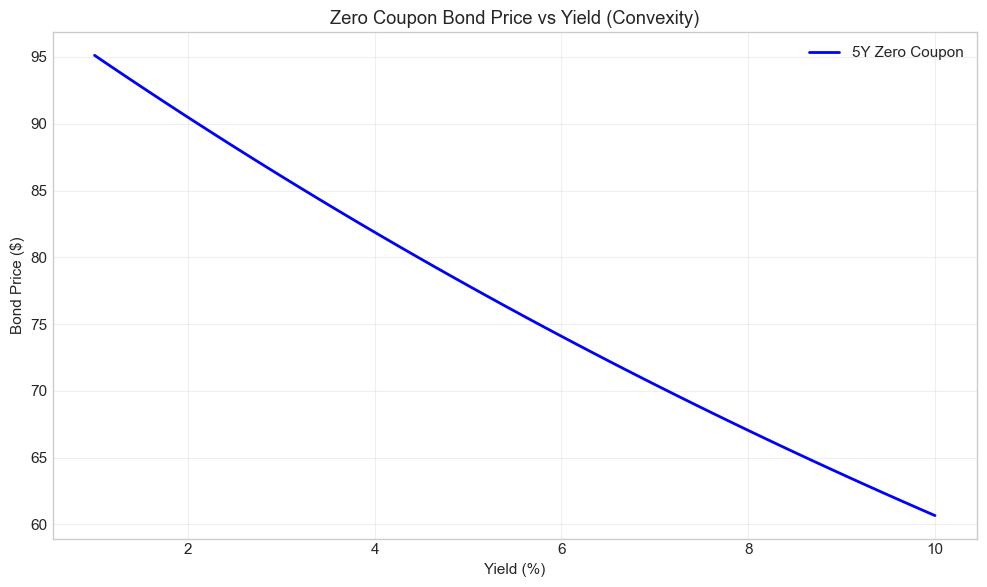

Convexity Demonstration:
Price at 5%: $77.88
Price at 4%: $81.87 (rate down 1%)
Price at 6%: $74.08 (rate up 1%)


In [3]:
import math

# Price zero coupon bond across different yields
yields = np.linspace(0.01, 0.10, 50)  # 1% to 10%
maturity = 5.0
face = 100.0

prices = [face * math.exp(-y * maturity) for y in yields]

plt.figure(figsize=(10, 6))
plt.plot(yields * 100, prices, 'b-', linewidth=2, label='5Y Zero Coupon')
plt.xlabel('Yield (%)')
plt.ylabel('Bond Price ($)')
plt.title('Zero Coupon Bond Price vs Yield (Convexity)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Note the convexity - price changes more for rate decreases than increases
print("Convexity Demonstration:")
print(f"Price at 5%: ${face * math.exp(-0.05 * maturity):.2f}")
print(f"Price at 4%: ${face * math.exp(-0.04 * maturity):.2f} (rate down 1%)")
print(f"Price at 6%: ${face * math.exp(-0.06 * maturity):.2f} (rate up 1%)")

### 1.3 Duration vs Maturity

For zero coupon bonds, **Macaulay duration equals maturity**.

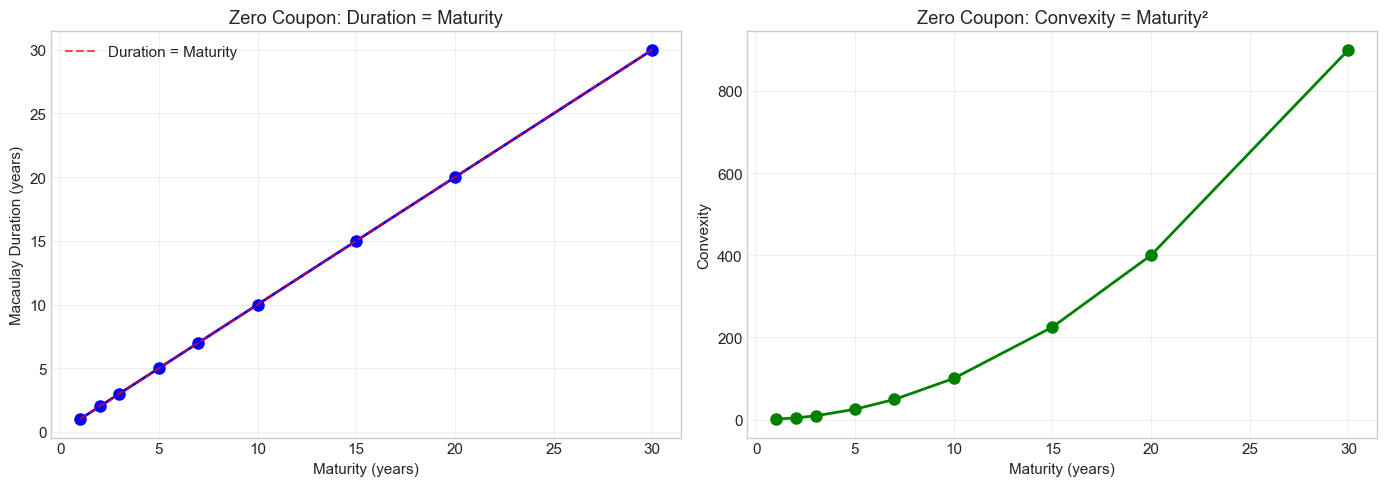

In [4]:
maturities = [1, 2, 3, 5, 7, 10, 15, 20, 30]
durations = []
convexities = []

for T in maturities:
    df = math.exp(-0.04 * T)  # 4% rate
    bond = IrBondZeroCouponSimple(face_value=100, maturity=T, discount_factor=df)
    g = pricer.greeks(bond)
    durations.append(g['macaulay_duration'])
    convexities.append(g['convexity'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(maturities, durations, 'b-o', linewidth=2, markersize=8)
ax1.plot(maturities, maturities, 'r--', alpha=0.7, label='Duration = Maturity')
ax1.set_xlabel('Maturity (years)')
ax1.set_ylabel('Macaulay Duration (years)')
ax1.set_title('Zero Coupon: Duration = Maturity')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(maturities, convexities, 'g-o', linewidth=2, markersize=8)
ax2.set_xlabel('Maturity (years)')
ax2.set_ylabel('Convexity')
ax2.set_title('Zero Coupon: Convexity = Maturity²')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## Part 2: Fixed Rate (Coupon) Bonds

A fixed rate bond pays periodic coupons plus face value at maturity.

### 2.1 Coupon Bond Pricing

$$PV = \sum_{i=1}^{n} C_i \times DF(T_i) + Face \times DF(T_n)$$

In [5]:
# Helper to generate discount factors from a flat yield
def generate_dfs(times, yield_rate):
    return tuple(math.exp(-yield_rate * t) for t in times)

# Create a 5-year annual coupon bond
coupon_times = (1.0, 2.0, 3.0, 4.0, 5.0)
yield_rate = 0.04  # 4% flat yield

fr_bond = IrBondFixedRateSimple(
    face_value=100.0,
    coupon_rate=0.05,  # 5% annual coupon
    coupon_times=coupon_times,
    coupon_dfs=generate_dfs(coupon_times, yield_rate),
    accrued_interest=0.0,
)

fr_pricer = IrBondFixedRatePricerSimple()

pv = fr_pricer.price(fr_bond)
greeks = fr_pricer.greeks(fr_bond)

print("=== Fixed Rate Bond ===")
print(f"Face Value:   ${fr_bond.face_value:.2f}")
print(f"Coupon Rate:  {fr_bond.coupon_rate:.2%}")
print(f"Maturity:     {fr_bond.maturity:.1f} years")
print(f"Coupon/Year:  ${fr_bond.coupon_amount:.2f}")
print()
print(f"Present Value: ${pv:.4f}")
print(f"(Premium bond: coupon > yield, so PV > 100)")
print()
print("=== Risk Measures ===")
print(f"DV01:             ${greeks['dv01']:.4f}")
print(f"Macaulay Duration: {greeks['macaulay_duration']:.4f} years")
print(f"Modified Duration: {greeks['modified_duration']:.4f}")
print(f"Convexity:        {greeks['convexity']:.4f}")

=== Fixed Rate Bond ===
Face Value:   $100.00
Coupon Rate:  5.00%
Maturity:     5.0 years
Coupon/Year:  $5.00

Present Value: $104.0816
(Premium bond: coupon > yield, so PV > 100)

=== Risk Measures ===
DV01:             $0.0474
Macaulay Duration: 4.5562 years
Modified Duration: 4.5562
Convexity:        21.9109


### 2.2 Clean vs Dirty Price

- **Dirty Price**: Full price (what you pay)
- **Clean Price**: Price excluding accrued interest (what's quoted)

In [6]:
# Bond with accrued interest (half-year since last coupon)
bond_with_accrued = IrBondFixedRateSimple(
    face_value=100.0,
    coupon_rate=0.05,
    coupon_times=(0.5, 1.5, 2.5, 3.5, 4.5),  # Next coupon in 6 months
    coupon_dfs=generate_dfs((0.5, 1.5, 2.5, 3.5, 4.5), 0.04),
    accrued_interest=2.5,  # Half year of 5% coupon
)

dirty = fr_pricer.price(bond_with_accrued)
clean = fr_pricer.clean_price(bond_with_accrued)
accrued = bond_with_accrued.accrued_interest

print("=== Clean vs Dirty Price ===")
print(f"Dirty Price:      ${dirty:.4f} (what you pay)")
print(f"Accrued Interest: ${accrued:.4f} (seller's portion of next coupon)")
print(f"Clean Price:      ${clean:.4f} (quoted price)")
print()
print(f"Verification: Dirty - Accrued = Clean")
print(f"             ${dirty:.4f} - ${accrued:.4f} = ${dirty - accrued:.4f}")

=== Clean vs Dirty Price ===
Dirty Price:      $106.1842 (what you pay)
Accrued Interest: $2.5000 (seller's portion of next coupon)
Clean Price:      $103.6842 (quoted price)

Verification: Dirty - Accrued = Clean
             $106.1842 - $2.5000 = $103.6842


### 2.3 Duration vs Coupon Rate

**Higher coupon → Lower duration** (cash flows weighted earlier)

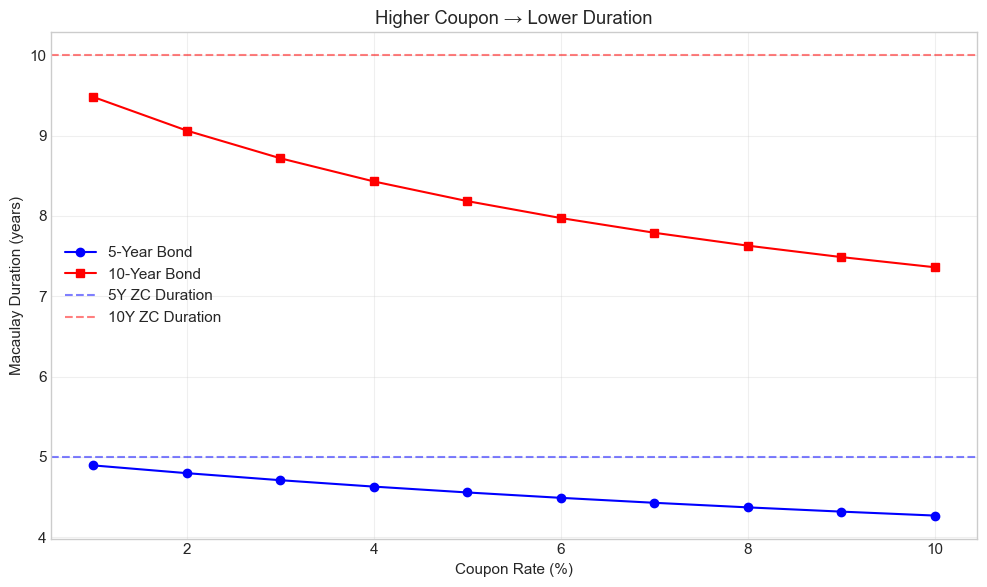

In [7]:
coupon_rates = np.arange(0.01, 0.11, 0.01)  # 1% to 10%
durations_5y = []
durations_10y = []

# 5-year bonds
times_5y = (1.0, 2.0, 3.0, 4.0, 5.0)
dfs_5y = generate_dfs(times_5y, 0.04)

# 10-year bonds
times_10y = tuple(float(i) for i in range(1, 11))
dfs_10y = generate_dfs(times_10y, 0.04)

for c in coupon_rates:
    # 5-year
    bond_5y = IrBondFixedRateSimple(
        face_value=100.0, coupon_rate=c,
        coupon_times=times_5y, coupon_dfs=dfs_5y, accrued_interest=0.0
    )
    durations_5y.append(fr_pricer.greeks(bond_5y)['macaulay_duration'])
    
    # 10-year
    bond_10y = IrBondFixedRateSimple(
        face_value=100.0, coupon_rate=c,
        coupon_times=times_10y, coupon_dfs=dfs_10y, accrued_interest=0.0
    )
    durations_10y.append(fr_pricer.greeks(bond_10y)['macaulay_duration'])

plt.figure(figsize=(10, 6))
plt.plot(coupon_rates * 100, durations_5y, 'b-o', label='5-Year Bond', markersize=6)
plt.plot(coupon_rates * 100, durations_10y, 'r-s', label='10-Year Bond', markersize=6)
plt.axhline(y=5.0, color='b', linestyle='--', alpha=0.5, label='5Y ZC Duration')
plt.axhline(y=10.0, color='r', linestyle='--', alpha=0.5, label='10Y ZC Duration')
plt.xlabel('Coupon Rate (%)')
plt.ylabel('Macaulay Duration (years)')
plt.title('Higher Coupon → Lower Duration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Part 3: Bond Options (Black76)

Bond options are priced using the **Black76 model** on the forward bond price.

### 3.1 Bond Option Pricing

In [8]:
# 6-month call option on a bond
call = IrBondEuropeanOptionSimple(
    notional=1_000_000,         # $1M face value
    strike=102.0,               # Strike at 102%
    expiry=0.5,                 # 6 months
    forward_bond_price=103.5,   # Forward at 103.5%
    vol=0.08,                   # 8% bond price vol
    discount_factor=0.975,
    option_type="call",
)

put = IrBondEuropeanOptionSimple(
    notional=1_000_000,
    strike=102.0,
    expiry=0.5,
    forward_bond_price=103.5,
    vol=0.08,
    discount_factor=0.975,
    option_type="put",
)

opt_pricer = IrBondEuropeanOptionB76PricerSimple()

call_pv = opt_pricer.price(call)
put_pv = opt_pricer.price(put)
call_greeks = opt_pricer.greeks(call)

print("=== Bond Option Pricing ===")
print(f"Forward Bond Price: {call.forward_bond_price}")
print(f"Strike:            {call.strike}")
print(f"Expiry:            {call.expiry} years")
print(f"Volatility:        {call.vol:.1%}")
print()
print(f"Call Value: ${call_pv:,.2f}")
print(f"Put Value:  ${put_pv:,.2f}")
print()
print("=== Call Greeks ===")
print(f"Delta: {call_greeks['delta']:,.0f}")
print(f"Gamma: {call_greeks['gamma']:,.2f}")
print(f"Vega:  {call_greeks['vega']:,.2f}")
print(f"Theta: {call_greeks['theta']:,.2f}")

=== Bond Option Pricing ===
Forward Bond Price: 103.5
Strike:            102.0
Expiry:            0.5 years
Volatility:        8.0%

Call Value: $3,066,638.61
Put Value:  $1,604,138.61

=== Call Greeks ===
Delta: 597,380
Gamma: 63,766.59
Vega:  27,323,346.20
Theta: -2,030,586.56


### 3.2 Put-Call Parity

For European bond options: $C - P = DF \times (F - K)$

In [9]:
# Verify put-call parity
N = 1_000_000
df = 0.975
F = 103.5
K = 102.0

expected_diff = N * df * (F - K)
actual_diff = call_pv - put_pv

print("=== Put-Call Parity ===")
print(f"Call - Put = DF × (F - K)")
print()
print(f"Actual (Call - Put):    ${actual_diff:,.2f}")
print(f"Expected DF × (F - K):  ${expected_diff:,.2f}")
print(f"Difference:             ${abs(actual_diff - expected_diff):,.6f}")
print(f"Parity holds: {abs(actual_diff - expected_diff) < 0.01}")

=== Put-Call Parity ===
Call - Put = DF × (F - K)

Actual (Call - Put):    $1,462,500.00
Expected DF × (F - K):  $1,462,500.00
Difference:             $0.000000
Parity holds: True


### 3.3 Option Value vs Forward Price

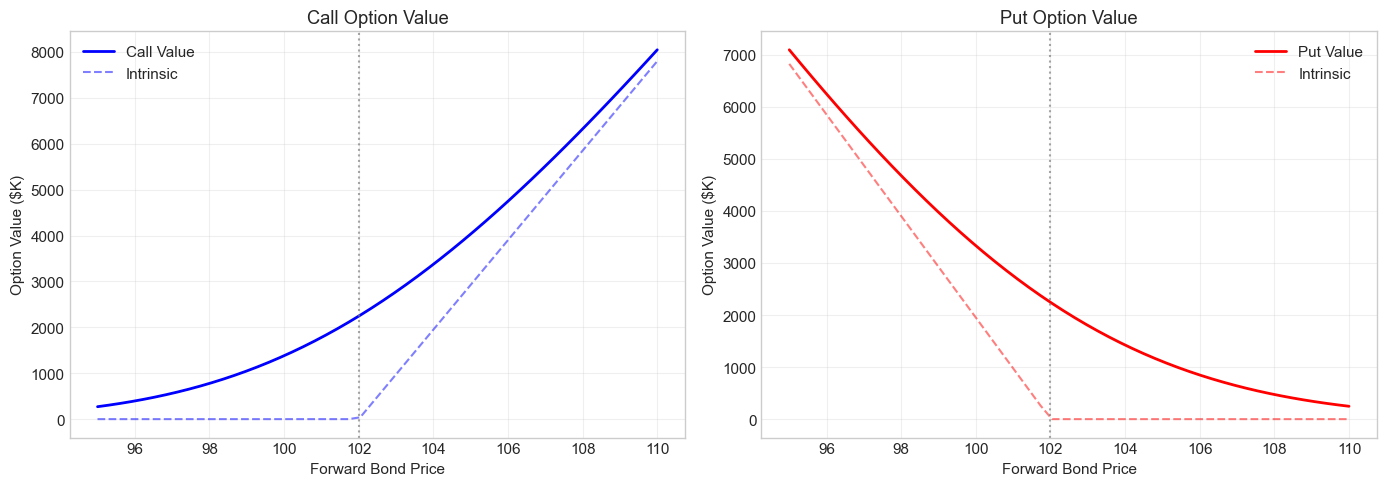

In [10]:
forwards = np.linspace(95, 110, 50)
call_values = []
put_values = []
intrinsic_call = []
intrinsic_put = []

K = 102.0
N = 1_000_000
df = 0.975

for F in forwards:
    c = IrBondEuropeanOptionSimple(
        notional=N, strike=K, expiry=0.5, forward_bond_price=F,
        vol=0.08, discount_factor=df, option_type="call"
    )
    p = IrBondEuropeanOptionSimple(
        notional=N, strike=K, expiry=0.5, forward_bond_price=F,
        vol=0.08, discount_factor=df, option_type="put"
    )
    call_values.append(opt_pricer.price(c) / 1000)  # Scale to $K
    put_values.append(opt_pricer.price(p) / 1000)
    intrinsic_call.append(N * df * max(F - K, 0) / 1000)
    intrinsic_put.append(N * df * max(K - F, 0) / 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(forwards, call_values, 'b-', linewidth=2, label='Call Value')
ax1.plot(forwards, intrinsic_call, 'b--', alpha=0.5, label='Intrinsic')
ax1.axvline(x=K, color='gray', linestyle=':', alpha=0.7)
ax1.set_xlabel('Forward Bond Price')
ax1.set_ylabel('Option Value ($K)')
ax1.set_title('Call Option Value')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(forwards, put_values, 'r-', linewidth=2, label='Put Value')
ax2.plot(forwards, intrinsic_put, 'r--', alpha=0.5, label='Intrinsic')
ax2.axvline(x=K, color='gray', linestyle=':', alpha=0.7)
ax2.set_xlabel('Forward Bond Price')
ax2.set_ylabel('Option Value ($K)')
ax2.set_title('Put Option Value')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.4 Delta Surface

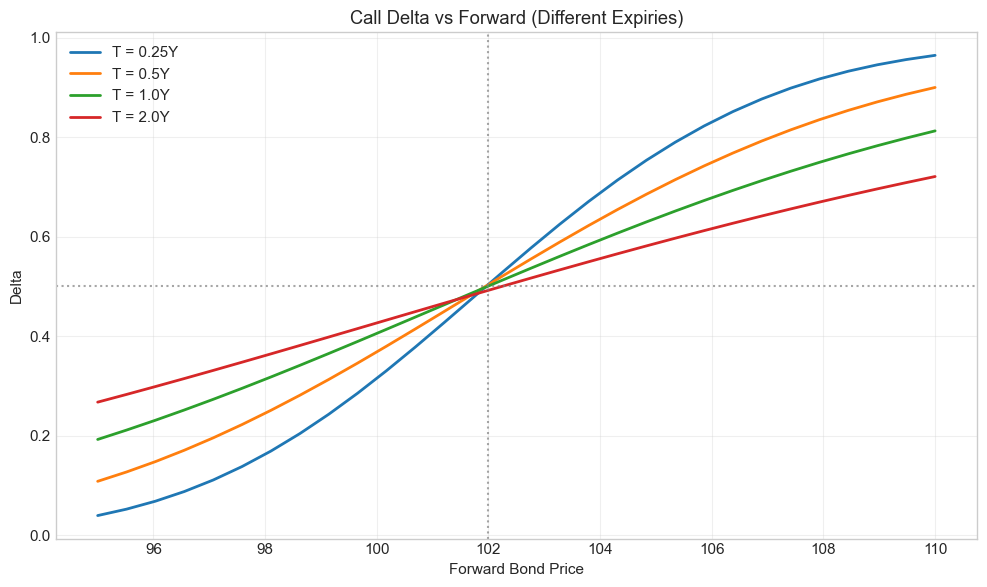

In [11]:
forwards = np.linspace(95, 110, 30)
expiries = [0.25, 0.5, 1.0, 2.0]

plt.figure(figsize=(10, 6))

for T in expiries:
    deltas = []
    for F in forwards:
        c = IrBondEuropeanOptionSimple(
            notional=1, strike=K, expiry=T, forward_bond_price=F,
            vol=0.08, discount_factor=math.exp(-0.03 * T), option_type="call"
        )
        deltas.append(opt_pricer.greeks(c)['delta'])
    plt.plot(forwards, deltas, linewidth=2, label=f'T = {T}Y')

plt.axvline(x=K, color='gray', linestyle=':', alpha=0.7)
plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.7)
plt.xlabel('Forward Bond Price')
plt.ylabel('Delta')
plt.title('Call Delta vs Forward (Different Expiries)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Summary

### Key Formulas

| Instrument | Formula |
|------------|--------|
| Zero Coupon | $PV = Face \times DF(T)$ |
| Coupon Bond | $PV = \sum C_i \times DF_i + Face \times DF_n$ |
| Duration | $D = \frac{\sum t_i \times CF_i \times DF_i}{PV}$ |
| Bond Option | Black76 on forward price |

### Key Concepts

1. **Zero coupon duration = maturity**
2. **Higher coupon → lower duration**
3. **Clean = Dirty - Accrued**
4. **Put-call parity: C - P = DF(F - K)**
5. **Bond options use price vol, not yield vol**